# 4장 1강 프로젝트 개요와 문제 정의

## 실습 목표

- Ravenstack의 5개 테이블을 탐색하고 분석 단위와 연결 키를 설명한다.
- 데이터 품질과 기초 분포를 확인하여 분석 가능한 근거를 만든다.
- EDA 결과를 바탕으로 측정 가능한 문제, 목표 지표, 초기 가설을 정의한다.
- 이후 강의에서 검증할 분석 흐름을 일관되게 설계한다.

## 실습 환경 / 데이터

- Python / Colab, `pandas`, `matplotlib`
- `ravenstack_accounts.csv`: 계정 속성과 계정 이탈 여부
- `ravenstack_subscriptions.csv`: 구독 이력과 MRR, 플랜, 이탈 여부
- `ravenstack_feature_usage.csv`: 기능별 사용량과 오류
- `ravenstack_support_tickets.csv`: 문의 처리와 만족도
- `ravenstack_churn_events.csv`: 이탈 사유와 환불

> 분석 기준: 계정의 대표 이탈 지표는 `accounts.churn_flag`로 정의합니다. 서로 다른 테이블의 같은 이름 컬럼을 임의로 섞지 않습니다.

## 실습 준비

### 데이터 불러오기

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

file_names = {
    "accounts": "ravenstack_accounts.csv",
    "subscriptions": "ravenstack_subscriptions.csv",
    "feature_usage": "ravenstack_feature_usage.csv",
    "support_tickets": "ravenstack_support_tickets.csv",
    "churn_events": "ravenstack_churn_events.csv",
}

candidate_dirs = [Path("."), Path("upload"), Path("/content")]
data_dir = next((d for d in candidate_dirs if all((d / f).exists() for f in file_names.values())), None)
if data_dir is None:
    raise FileNotFoundError("5개 CSV를 노트북과 같은 폴더(또는 /content)에 업로드해 주세요.")

data = {name: pd.read_csv(data_dir / file) for name, file in file_names.items()}
accounts = data["accounts"]
subscriptions = data["subscriptions"]
feature_usage = data["feature_usage"]
support_tickets = data["support_tickets"]
churn_events = data["churn_events"]

print("데이터 폴더:", data_dir.resolve())
for name, df in data.items():
    print(f"{name:16s}: {df.shape[0]:,}행 × {df.shape[1]}열")

데이터 폴더: C:\first-project
accounts        : 500행 × 10열
subscriptions   : 5,000행 × 14열
feature_usage   : 25,000행 × 8열
support_tickets : 2,000행 × 9열
churn_events    : 600행 × 9열


### 분석 대상 컬럼 확인

각 테이블의 앞부분과 컬럼을 확인하세요.

In [2]:
for name, df in data.items():
    print(f"\n[{name}] 컬럼")
    print(df.columns.tolist())
    display(df.head(2))


[accounts] 컬럼
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True



[subscriptions] 컬럼
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True



[feature_usage] 컬럼
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False



[support_tickets] 컬럼
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False



[churn_events] 컬럼
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN


### 결측치 및 자료형 확인

날짜 컬럼을 변환하고 키 중복을 확인합니다.

In [3]:
# 날짜 컬럼을 datetime으로 변환합니다.
date_columns = {
    "accounts": ["signup_date"],
    "subscriptions": ["start_date", "end_date"],
    "feature_usage": ["usage_date"],
    "support_tickets": ["submitted_at", "closed_at"],
    "churn_events": ["churn_date"],
}
for name, columns in date_columns.items():
    for column in columns:
        data[name][column] = pd.to_datetime(data[name][column], errors="coerce")

# 분석 단위와 키를 확인합니다.
key_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id",
}
for name, key in key_columns.items():
    df = data[name]
    print(f"{name:16s} | key 중복 {df[key].duplicated().sum():>2} | 전체 행 중복 {df.duplicated().sum():>2}")

accounts         | key 중복  0 | 전체 행 중복  0
subscriptions    | key 중복  0 | 전체 행 중복  0
feature_usage    | key 중복 21 | 전체 행 중복  0
support_tickets  | key 중복  0 | 전체 행 중복  0
churn_events     | key 중복  0 | 전체 행 중복  0


### 기초 통계량과 분포 확인

아래 코드로 수치형 변수와 주요 범주의 분포를 확인하세요.

In [4]:
display(accounts[["seats", "churn_flag"]].describe())
display(accounts["plan_tier"].value_counts().rename("accounts"))
display(churn_events["reason_code"].value_counts().rename("events"))

,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


plan_tier
Pro           178
Basic         168
Enterprise    154
Name: accounts, dtype: int64

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: events, dtype: int64

---

## 필수 1 — 5개 테이블의 EDA 요약

각 테이블에 대해 다음 항목을 하나의 요약표로 만드세요.

1. 행 수와 열 수
2. 전체 결측치 수
3. 완전히 동일한 중복 행 수
4. 날짜 범위(최솟값~최댓값)

그 후 다음 질문에 답하세요.

- 결측치가 있는 테이블과 컬럼은 무엇인가요?
- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?
- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.

In [5]:
# 필수 1: 테이블별 EDA 요약표
summary_rows = []

for name, df in data.items():
    # [요구사항 1] 행 수 / 열 수
    n_rows, n_cols = df.shape

    # [요구사항 2] 전체 결측치 수 (+ 어떤 컬럼에 있는지도 같이 기록)
    missing = df.isna().sum()
    missing_cols = missing[missing > 0]
    missing_text = ", ".join(f"{col}({cnt:,})" for col, cnt in missing_cols.items()) or "-"

    # [요구사항 3] 완전히 동일한 중복 행 수
    dup_rows = df.duplicated().sum()

    # [요구사항 4] 날짜 범위: 테이블 내 모든 날짜 컬럼의 최솟값 ~ 최댓값
    cols = date_columns[name]
    date_min = min(df[c].min() for c in cols)
    date_max = max(df[c].max() for c in cols)

    summary_rows.append({
        "table": name,
        "rows": n_rows,
        "cols": n_cols,
        "total_missing": int(missing.sum()),
        "missing_columns": missing_text,
        "duplicate_rows": int(dup_rows),
        "date_columns": ", ".join(cols),
        "date_min": date_min.date(),
        "date_max": date_max.date(),
    })

eda_summary = pd.DataFrame(summary_rows)
display(eda_summary)

# ---------- 서술 답안 근거 출력 ----------
print("\n[근거 1] 결측치가 있는 컬럼과 결측 비율")
for name, df in data.items():
    miss = df.isna().sum()
    for col, cnt in miss[miss > 0].items():
        print(f"  {name}.{col}: {cnt:,}건 / {len(df):,}건 ({cnt / len(df):.1%})")

print("\n[근거 2] subscriptions.end_date 결측 vs churn_flag (결측 = 아직 활성 구독)")
print(pd.crosstab(subscriptions["churn_flag"], subscriptions["end_date"].isna(),
                  rownames=["churn_flag"], colnames=["end_date 결측"]))

print("\n[근거 3] support_tickets.satisfaction_score 결측 = 설문 무응답")
print(f"  무응답 비율: {support_tickets['satisfaction_score'].isna().mean():.1%}")
print(f"  응답자 점수 분포:\n{support_tickets['satisfaction_score'].value_counts().sort_index().to_string()}")

print("\n[근거 4] churn_events.feedback_text 결측 = 선택 입력 미작성")
print(f"  미작성 비율: {churn_events['feedback_text'].isna().mean():.1%}")

print("\n[품질 이슈 A] 키 중복 (전체 행 중복은 0이지만 PK 중복이 있는지)")
for name, key in key_columns.items():
    print(f"  {name:16s} {key:16s} 중복 {data[name][key].duplicated().sum()}건")

print("\n[품질 이슈 B] 테이블 간 이탈 정의 불일치")
churned_ids = set(accounts.loc[accounts["churn_flag"], "account_id"])
event_ids = set(churn_events["account_id"])
print(f"  accounts.churn_flag=True 계정 수           : {len(churned_ids)}")
print(f"  churn_events에 등장한 고유 계정 수          : {len(event_ids)} (이벤트 {len(churn_events)}건)")
print(f"  churn_flag=True인데 churn_events에 없는 계정: {len(churned_ids - event_ids)}")
print(f"  churn_flag=False인데 churn_events에 있는 계정: {len(event_ids - churned_ids)}")
print(f"  계정 기준 이탈률(accounts)      : {accounts['churn_flag'].mean():.1%}")
print(f"  구독 기준 이탈률(subscriptions) : {subscriptions['churn_flag'].mean():.1%}")

,table,rows,cols,total_missing,missing_columns,duplicate_rows,date_columns,date_min,date_max
0,accounts,500,10,0,-,0,signup_date,2023-01-02,2024-12-31
1,subscriptions,5000,14,4514,"end_date(4,514)",0,"start_date, end_date",2023-01-09,2024-12-31
2,feature_usage,25000,8,0,-,0,usage_date,2023-01-01,2024-12-31
3,support_tickets,2000,9,825,satisfaction_score(825),0,"submitted_at, closed_at",2023-01-02,2024-12-31
4,churn_events,600,9,148,feedback_text(148),0,churn_date,2023-01-25,2024-12-31



[근거 1] 결측치가 있는 컬럼과 결측 비율
  subscriptions.end_date: 4,514건 / 5,000건 (90.3%)
  support_tickets.satisfaction_score: 825건 / 2,000건 (41.2%)
  churn_events.feedback_text: 148건 / 600건 (24.7%)

[근거 2] subscriptions.end_date 결측 vs churn_flag (결측 = 아직 활성 구독)
end_date 결측  False  True 
churn_flag               
False            0   4514
True           486      0

[근거 3] support_tickets.satisfaction_score 결측 = 설문 무응답
  무응답 비율: 41.2%
  응답자 점수 분포:
satisfaction_score
3.0    396
4.0    405
5.0    374

[근거 4] churn_events.feedback_text 결측 = 선택 입력 미작성
  미작성 비율: 24.7%

[품질 이슈 A] 키 중복 (전체 행 중복은 0이지만 PK 중복이 있는지)
  accounts         account_id       중복 0건
  subscriptions    subscription_id  중복 0건
  feature_usage    usage_id         중복 21건
  support_tickets  ticket_id        중복 0건
  churn_events     churn_event_id   중복 0건

[품질 이슈 B] 테이블 간 이탈 정의 불일치
  accounts.churn_flag=True 계정 수           : 110
  churn_events에 등장한 고유 계정 수          : 352 (이벤트 600건)
  churn_flag=True인데 churn_events에 없는 계정: 35
  churn_flag=Fals

### 필수 1 서술 답안

**결측치가 있는 테이블과 컬럼**

| 테이블 | 컬럼 | 결측 수 | 비율 | 결측의 의미 |
|---|---|---:|---:|---|
| subscriptions | `end_date` | 4,514 | 90.3% | 아직 종료되지 않은 **활성 구독** (churn_flag=False와 정확히 일치) |
| support_tickets | `satisfaction_score` | 825 | 41.2% | 고객이 만족도 설문에 **응답하지 않음** |
| churn_events | `feedback_text` | 148 | 24.7% | 이탈 시 코멘트를 **작성하지 않음** (선택 입력) |

accounts, feature_usage는 결측치가 없고, 5개 테이블 모두 완전 중복 행은 0건입니다. 날짜 범위는 모두 2023-01 ~ 2024-12-31(약 2년)입니다.

**결측치를 곧바로 삭제하면 안 되는 이유**

결측 자체가 정보이기 때문입니다. `end_date` 결측은 "아직 구독 중"이라는 뜻이라, 결측 행을 지우면 구독의 90%가 사라지고 **이탈한 구독만 남아** 분석이 완전히 왜곡됩니다. `satisfaction_score` 무응답도 불만 고객이 응답을 안 했을 수 있어(MNAR 가능성) 지우면 만족도가 과대평가될 수 있고, 행을 삭제하면 같은 행의 응답시간·에스컬레이션 정보까지 함께 잃습니다. 따라서 삭제 대신 "활성 구독", "무응답" 같은 **상태로 해석하거나 별도 플래그**로 남겨야 합니다.

**분석 전에 주의할 데이터 품질 문제**

테이블 간 **이탈 정의가 서로 일치하지 않습니다.** `accounts.churn_flag=True`인 계정은 110개(22.0%)인데, `churn_events`에는 352개 계정이 등장하고 그중 277개는 `churn_flag=False`입니다. 반대로 churn_flag=True 계정 중 35개는 이탈 이벤트가 없습니다. 구독 기준 이탈률(9.7%)도 계정 기준(22.0%)과 다릅니다. 그래서 과제 기준대로 **대표 이탈 지표는 `accounts.churn_flag` 하나로 고정**하고, `churn_events`는 사유 참고용으로만 써야 합니다. (추가로 `satisfaction_score`는 README상 1~5점인데 실제 응답은 3~5점뿐이라 불만 고객이 응답에서 빠졌을 가능성이 크고, `feature_usage.usage_id`는 전체 행 중복은 없지만 PK가 21건 중복되어 있어 키로 조인·집계할 때 주의가 필요합니다.)

---

## 필수 2 — 근거를 연결해 분석 문제 정의하기

계정 테이블을 기준으로 다음을 분석하세요.

1. 전체 계정 이탈률을 계산하세요.
2. `industry`, `referral_source`, `is_trial`별 계정 수와 이탈률을 계산하세요.
3. 표본이 20개 이상인 세그먼트 중 전체 이탈률보다 높은 구간을 찾으세요.
4. 결과를 근거로 **문제 정의 1문장**, **현재 지표**, **목표 지표**를 작성하세요.
5. 이탈률이 가장 높은 산업군을 막대그래프로 비교하세요.

> 목표값은 정답이 하나가 아닙니다. 현재 값보다 개선된 수치이며, 지표·대상·기간(또는 평가 시점)이 드러나게 작성하세요.

[1] 전체 계정 이탈률: 22.00% (110 / 500 계정)

[2] industry별 계정 수 · 이탈률


,accounts,churned,churn_rate,diff_vs_overall_pp,n_ok(>=20),above_overall
industry,,,,,,
DevTools,113,35,31.0%,+9.0,True,True
FinTech,112,25,22.3%,+0.3,True,True
HealthTech,96,21,21.9%,-0.1,True,False
EdTech,79,13,16.5%,-5.5,True,False
Cybersecurity,100,16,16.0%,-6.0,True,False



[2] referral_source별 계정 수 · 이탈률


,accounts,churned,churn_rate,diff_vs_overall_pp,n_ok(>=20),above_overall
referral_source,,,,,,
event,96,29,30.2%,+8.2,True,True
other,103,25,24.3%,+2.3,True,True
ads,98,23,23.5%,+1.5,True,True
organic,114,20,17.5%,-4.5,True,False
partner,89,13,14.6%,-7.4,True,False



[2] is_trial별 계정 수 · 이탈률


,accounts,churned,churn_rate,diff_vs_overall_pp,n_ok(>=20),above_overall
is_trial,,,,,,
True,97,25,25.8%,+3.8,True,True
False,403,85,21.1%,-0.9,True,False



[3] 표본 20개 이상 & 전체(22.0%)보다 이탈률이 높은 세그먼트


,dimension,segment,accounts,churned,churn_rate,diff_vs_overall_pp
0,industry,DevTools,113,35,31.0%,+9.0
1,referral_source,event,96,29,30.2%,+8.2
2,is_trial,True,97,25,25.8%,+3.8
3,referral_source,other,103,25,24.3%,+2.3
4,referral_source,ads,98,23,23.5%,+1.5
5,industry,FinTech,112,25,22.3%,+0.3



[4] 문제 정의 근거
  최고 이탈 산업: DevTools → 31.0% (35/113), 전체 대비 +9.0%p
  DevTools 이탈 계정이 전체 이탈 계정에서 차지하는 비중: 31.8%
  DevTools 이탈률을 전체 평균(22%)까지 낮추면 줄어드는 이탈 계정 수 ≈ 10개
  참고) 플랜별 이탈률:
plan_tier
Basic         22.0%
Enterprise    22.1%
Pro           21.9%


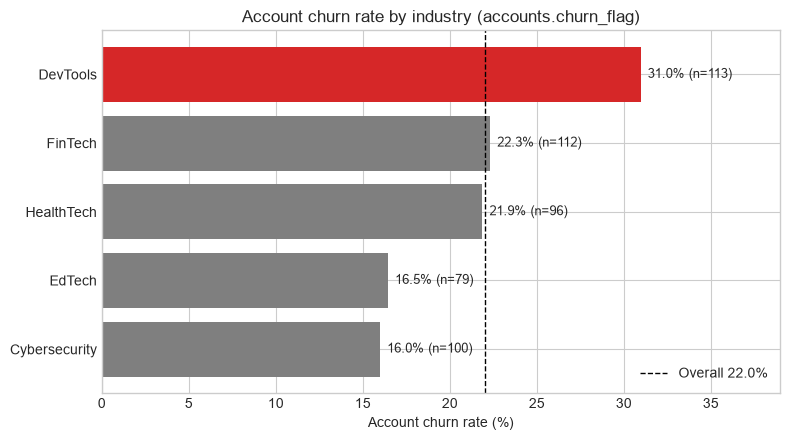

In [6]:
# [요구사항 1] 전체 계정 이탈률 (대표 지표: accounts.churn_flag)
overall_churn_rate = accounts["churn_flag"].mean()
n_churned = accounts["churn_flag"].sum()
print(f"[1] 전체 계정 이탈률: {overall_churn_rate:.2%} ({n_churned} / {len(accounts)} 계정)")

# [요구사항 2] 세그먼트별 계정 수와 이탈률
MIN_N = 20
segment_results = {}
for column in ["industry", "referral_source", "is_trial"]:
    seg = (
        accounts.groupby(column)["churn_flag"]
        .agg(accounts="count", churned="sum", churn_rate="mean")
        .sort_values("churn_rate", ascending=False)
    )
    seg["diff_vs_overall_pp"] = (seg["churn_rate"] - overall_churn_rate) * 100   # 전체 대비 %p 차이
    seg["n_ok(>=20)"] = seg["accounts"] >= MIN_N
    seg["above_overall"] = seg["churn_rate"] > overall_churn_rate
    segment_results[column] = seg

    print(f"\n[2] {column}별 계정 수 · 이탈률")
    display(seg.style.format({"churn_rate": "{:.1%}", "diff_vs_overall_pp": "{:+.1f}"}))

# [요구사항 3] 표본 20개 이상 & 전체 이탈률보다 높은 세그먼트
high_risk = pd.concat(
    [seg.reset_index().rename(columns={col: "segment"}).assign(dimension=col)
     for col, seg in segment_results.items()]
)
high_risk["segment"] = high_risk["segment"].astype(str)
high_risk = (
    high_risk[high_risk["n_ok(>=20)"] & high_risk["above_overall"]]
    [["dimension", "segment", "accounts", "churned", "churn_rate", "diff_vs_overall_pp"]]
    .sort_values("churn_rate", ascending=False)
    .reset_index(drop=True)
)
print(f"\n[3] 표본 {MIN_N}개 이상 & 전체({overall_churn_rate:.1%})보다 이탈률이 높은 세그먼트")
display(high_risk.style.format({"churn_rate": "{:.1%}", "diff_vs_overall_pp": "{:+.1f}"}))

# [요구사항 4] 문제 정의에 쓸 핵심 수치
top_ind = segment_results["industry"].iloc[0]
top_ind_name = segment_results["industry"].index[0]
print(f"\n[4] 문제 정의 근거")
print(f"  최고 이탈 산업: {top_ind_name} → {top_ind['churn_rate']:.1%} "
      f"({int(top_ind['churned'])}/{int(top_ind['accounts'])}), 전체 대비 {top_ind['diff_vs_overall_pp']:+.1f}%p")
print(f"  {top_ind_name} 이탈 계정이 전체 이탈 계정에서 차지하는 비중: {top_ind['churned'] / n_churned:.1%}")
print(f"  {top_ind_name} 이탈률을 전체 평균({overall_churn_rate:.0%})까지 낮추면 "
      f"줄어드는 이탈 계정 수 ≈ {top_ind['churned'] - top_ind['accounts'] * overall_churn_rate:.0f}개")
print(f"  참고) 플랜별 이탈률:\n{accounts.groupby('plan_tier')['churn_flag'].mean().map('{:.1%}'.format).to_string()}")

# [요구사항 5] 산업별 이탈률 막대그래프 (한글 폰트 이슈를 피하려고 라벨은 영어)
ind = segment_results["industry"].sort_values("churn_rate", ascending=True)
colors = ["tab:red" if i == top_ind_name else "tab:gray" for i in ind.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(ind.index, ind["churn_rate"] * 100, color=colors)
ax.axvline(overall_churn_rate * 100, color="black", linestyle="--", linewidth=1,
           label=f"Overall {overall_churn_rate:.1%}")
for bar, (_, row) in zip(bars, ind.iterrows()):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{row['churn_rate']:.1%} (n={int(row['accounts'])})", va="center", fontsize=9)
ax.set_xlabel("Account churn rate (%)")
ax.set_title("Account churn rate by industry (accounts.churn_flag)")
ax.set_xlim(0, ind["churn_rate"].max() * 100 + 8)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 필수 2 서술 답안

- **발견한 핵심 패턴:** 전체 계정 이탈률은 **22.0%(110/500)** 입니다. 표본 20개 이상이면서 전체보다 높은 세그먼트는 **DevTools 31.0%(35/113, +9.0%p)**, **event 유입 30.2%(29/96, +8.2%p)**, 트라이얼 계정 25.8%(25/97, +3.8%p), other 유입 24.3%, ads 유입 23.5%, FinTech 22.3%입니다. 이 중 DevTools와 event 유입이 평균보다 약 8~9%p 높아 가장 두드러지고, 나머지는 +0.3~3.8%p로 차이가 작습니다. 반면 플랜 등급(Basic/Pro/Enterprise)별 이탈률은 모두 약 22%로 차이가 거의 없어, 이탈은 "무엇을 샀는가"보다 **"누가, 어디서 들어왔는가"** 쪽과 더 관련이 있어 보입니다. DevTools는 계정 수도 가장 많아(113개) 전체 이탈 계정의 약 32%를 차지합니다.
- **문제 정의:** DevTools 산업 계정의 이탈률이 31.0%로 전체 평균(22.0%)보다 9.0%p 높아, 가장 큰 고객군에서 이탈 계정이 집중적으로 발생하고 있다.
- **현재 지표:** DevTools 계정 이탈률 = `churn_flag=True`인 DevTools 계정 수 ÷ 전체 DevTools 계정 수 = **31.0% (35/113)**, 관측 기간 2023-01 ~ 2024-12 기준.
- **목표 지표:** 개선안 적용 후 **다음 분기(90일) 동안 신규·기존 DevTools 계정의 이탈률을 24% 이하**로 낮춘다(현재 대비 −7%p, 전체 평균 수준에 근접). 보조 지표로 event 유입 계정 이탈률 30.2% → 25% 이하를 함께 본다.
- **목표 지표가 적절한 이유:** ① 이탈률이 가장 높은 동시에 규모도 가장 큰 세그먼트라, 전체 평균까지만 낮춰도 이탈 계정이 약 10개 줄어 전체 이탈률 개선 효과가 큽니다. ② 대표 지표를 `accounts.churn_flag` 하나로 정의해 테이블 간 불일치 없이 같은 방식으로 반복 측정할 수 있습니다. ③ 목표값(24%)은 현재 값과 전체 평균 사이라 한 분기 안에 현실적으로 도달 가능한 수준이고, 대상(DevTools 계정)·지표(이탈률)·기간(90일)이 명확합니다. 단, 세그먼트당 표본이 100개 안팎이라 우연한 차이일 수 있으므로 2강에서 카이제곱 검정 등으로 유의성을 먼저 확인합니다.

---

## 과제 1 — 이탈 원인 가설과 검증 계획 세우기

필수 2에서 정의한 문제를 바탕으로 초기 가설 3개를 작성하세요.

- 적어도 2개는 현재 제공된 데이터로 검증 가능해야 합니다.
- 각 가설에 `필요한 테이블·컬럼`, `확인할 비교 또는 지표`, `우선순위`를 적으세요.
- 가장 먼저 검증할 가설 1개를 고르고 이유를 설명하세요.
- 2강 분석 → 3강 실험 → 4강 제안이 처음 문제와 어떻게 연결되는지 한 문장씩 작성하세요.

| 우선순위 | 가설 | 필요한 데이터 | 검증 방법 |
|---:|---|---|---|
| 1 | **지원 경험이 나쁜 계정일수록 이탈한다.** DevTools 계정은 첫 응답이 늦고 에스컬레이션이 잦으며 만족도가 낮아 이탈률이 높다. | `support_tickets`: `account_id`, `first_response_time_minutes`, `resolution_time_hours`, `escalation_flag`, `satisfaction_score`(무응답 별도 표시) + `accounts`: `industry`, `churn_flag` | 계정 단위로 티켓 지표를 집계(평균 첫 응답 시간, 에스컬레이션 비율, 평균 만족도, 무응답률)한 뒤 `accounts`와 조인 → 이탈/유지 그룹 비교(Mann-Whitney U / 비율 차이 검정), DevTools vs 기타 산업 비교 |
| 2 | **기능 오류를 많이 겪은 계정일수록 이탈한다.** 개발자 고객(DevTools)은 오류에 민감해, 오류율이 높으면 이탈한다. | `feature_usage`: `subscription_id`, `usage_count`, `error_count`, `is_beta_feature` → `subscriptions`: `subscription_id`, `account_id` → `accounts`: `industry`, `churn_flag` | 구독 → 계정으로 연결해 계정별 오류율(`error_count` 합 ÷ `usage_count` 합)과 베타 기능 사용 비중 계산 → 오류율 구간(사분위)별 이탈률 비교, 이탈/유지 그룹 간 평균 차이 검정 |
| 3 | **이벤트로 유입된 계정은 구매 의도가 약해 초기 정착 전에 이탈한다.** | `accounts`: `referral_source`, `signup_date`, `is_trial`, `churn_flag` + `subscriptions`: `start_date` + `feature_usage`: `usage_date`, `usage_count` (+ 실제 온보딩 여부는 **현재 데이터에 없음**) | 유입 채널별 가입 후 첫 30일 사용량·사용 기능 수 비교, event 유입 × 트라이얼 교차 이탈률 비교. 온보딩 참여 여부는 데이터가 없어 추가 수집 필요 |

**가장 먼저 검증할 가설: 1번(지원 경험)**
- `account_id`로 `accounts`와 바로 조인되어 구독을 거치는 2번보다 경로가 단순하고, 테이블 간 키 문제(usage_id 중복 등)의 영향을 덜 받습니다.
- 첫 응답 시간·에스컬레이션은 회사가 **직접 통제할 수 있는 변수**라, 검증되면 3강 실험(응답 SLA 개선 등)과 4강 제안으로 바로 이어집니다.
- `churn_events.reason_code`에서도 `support`가 104건으로 상위 사유에 속해 사전 근거가 있습니다(단, 이 테이블은 계정 이탈 플래그와 불일치하므로 참고용).

### 프로젝트 연결

- **2강 분석:** 가설 1·2를 계정 단위 데이터로 검증해, DevTools 이탈률이 31.0%로 높은 이유가 지원 경험 또는 기능 오류와 통계적으로 관련이 있는지 확인한다.
- **3강 실험:** 2강에서 확인된 원인(예: 첫 응답 지연)을 개선하는 조치를 DevTools 계정 일부에 적용하는 A/B 테스트를 설계해, 이탈률이 실제로 낮아지는지 인과적으로 검증한다.
- **4강 제안:** 실험 결과를 근거로 "DevTools 계정 이탈률 31.0% → 90일 내 24% 이하" 목표를 달성하기 위한 실행 방안과 기대 효과(감소할 이탈 계정 수, 보존 MRR)를 제시한다.

---

## 실습 마무리

- **어떤 분석 문제가 있었는가?** RavenStack의 계정 이탈률이 22.0%이고, 그중 DevTools 산업(31.0%)과 event 유입 채널(30.2%)이 평균보다 8~9%p 높아 특정 고객군에 이탈이 몰려 있다는 문제가 있었다. 또한 테이블마다 이탈 정의가 달라 어떤 지표를 기준으로 삼을지부터 정해야 했다.
- **어떤 통계적·분석적 방법을 적용했는가?** 테이블별 행·열 수, 결측치, 중복, 날짜 범위를 요약하는 EDA로 데이터 품질을 점검했고, 결측의 의미를 해석했다. 이어서 `accounts.churn_flag`를 대표 지표로 고정하고 `groupby`로 산업·유입 채널·트라이얼 여부별 이탈률을 구한 뒤, 표본 20개 이상 조건과 전체 평균 대비 %p 차이로 고위험 세그먼트를 골라 막대그래프로 비교했다.
- **무엇을 근거로 결론을 내렸는가?** 전체 이탈률 22.0% 대비 DevTools 31.0%(35/113)라는 차이, 그 세그먼트가 가장 커서 전체 이탈 계정의 약 32%를 차지한다는 점, 플랜별 이탈률 차이는 거의 없다는 점을 근거로 문제와 목표 지표를 정했다. 다만 이 결과는 기술 통계이므로, 차이가 유의한지와 원인은 2강의 가설 검정으로 확인해야 한다.